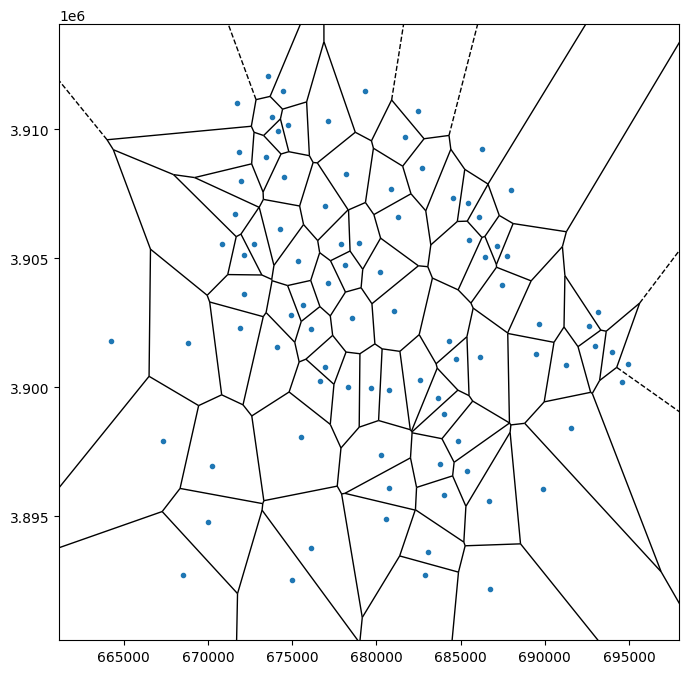

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial import Voronoi, voronoi_plot_2d
import geopandas as gpd
from matplotlib.colors import ListedColormap, BoundaryNorm

sites = pd.read_csv("input_data/sites.csv")
points = sites[["x", "y"]].values
voronoi = Voronoi(points)
fig, ax = plt.subplots(figsize=(8, 8))
voronoi_plot_2d(voronoi, ax=ax, show_vertices=False, line_colors='black')

plt.show()

In [61]:
def create_voronoi_polygons(voronoi_region, L_cell, sites, x_grid, y_grid, gdf, 
                           save_path=None):
    """
    Create polygons that trace Voronoi regions from grid cells.
    
    Parameters
    ----------
    voronoi_region : np.ndarray
        Array containing Voronoi region indices for each grid cell
    L_cell : float
        Length of each grid cell (assumed square)
    sites : pd.DataFrame
        DataFrame with site information
    x_grid : np.ndarray
        2D array of x-coordinates
    y_grid : np.ndarray
        2D array of y-coordinates
    gdf : gpd.GeoDataFrame
        Study area GeoDataFrame for clipping
    save_path : str, optional
        Path to save shapefile. If None, no file is saved
    
    Returns
    -------
    gpd.GeoDataFrame
        GeoDataFrame with Voronoi region polygons
    """
    from shapely.geometry import box
    
    voronoi_polygons = []
    site_indices = []
    
    # Create polygons for each Voronoi region
    for site_idx in range(len(sites)):
        site_mask = (voronoi_region == site_idx)
        
        if not np.any(site_mask):
            continue
        
        rows, cols = np.where(site_mask)
        
        # Create boxes for each cell
        boxes = []
        for row, col in zip(rows, cols):
            x_min = x_grid[row, col] - L_cell / 2
            x_max = x_grid[row, col] + L_cell / 2
            y_min = y_grid[row, col] - L_cell / 2
            y_max = y_grid[row, col] + L_cell / 2
            boxes.append(box(x_min, y_min, x_max, y_max))
        
        # Union all boxes into single polygon
        if boxes:
            region_polygon = gpd.GeoSeries(boxes).union_all()
            voronoi_polygons.append(region_polygon)
            site_indices.append(site_idx)
    
    # Create GeoDataFrame
    voronoi_gdf = gpd.GeoDataFrame(
        {'site_id': site_indices, 'geometry': voronoi_polygons},
        crs=gdf.crs
    )
    
    # Clip to study area boundary
    study_area_union = gdf.geometry.union_all()
    voronoi_gdf['geometry'] = voronoi_gdf.geometry.intersection(study_area_union)
    
    # Save if path provided
    if save_path:
        voronoi_gdf.to_file(save_path, engine='pyogrio')
        print(f"Voronoi polygons saved to {save_path}")
    
    print(f"Voronoi polygons created: {len(voronoi_gdf)} regions")
    
    return voronoi_gdf

Voronoi polygons created: 90 regions


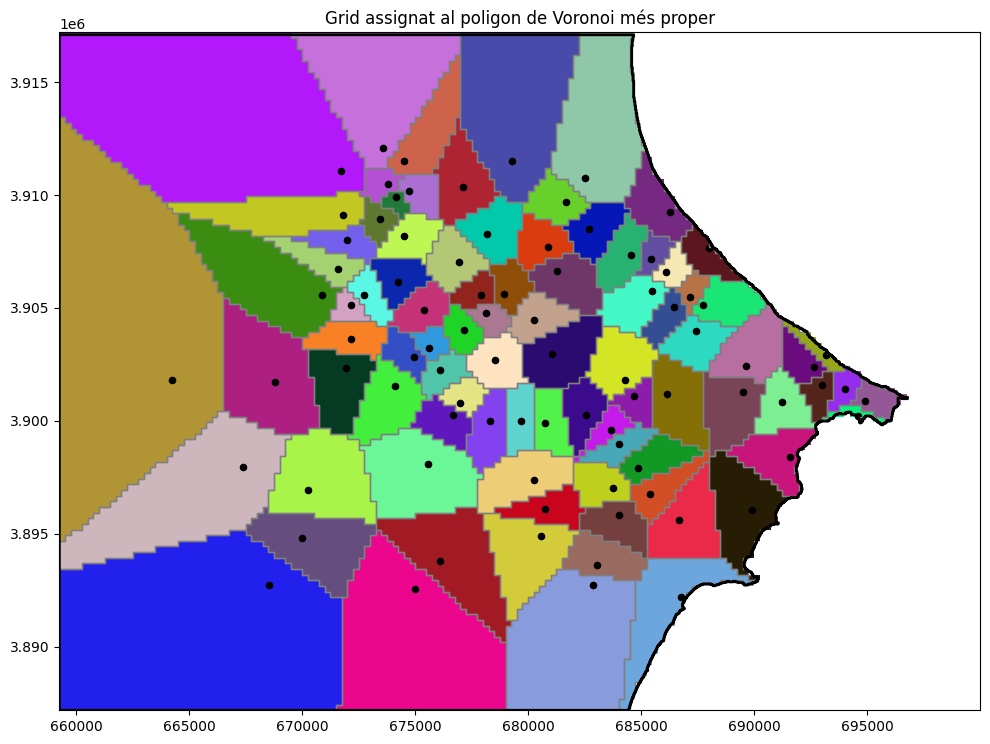

In [63]:
gdf = gpd.read_file("input_data/chebba_clipped.shp")

regular_grid = pd.read_pickle("input_data/regular_grid.pkl")
nx, ny = regular_grid['nx'], regular_grid['ny']

x_grid = np.asarray(regular_grid['x_center']).reshape(ny, nx)
y_grid = np.asarray(regular_grid['y_center']).reshape(ny, nx)
cell_centers = np.column_stack([x_grid.ravel(), y_grid.ravel()])

from scipy.spatial import cKDTree
kdtree = cKDTree(points)
cell_region_index = kdtree.query(cell_centers, k=1)[1].reshape(ny, nx)
regular_grid['voronoi_region'] = cell_region_index*regular_grid['mask']

voronoi_gdf = create_voronoi_polygons(
    voronoi_region=regular_grid['voronoi_region'],
    L_cell=regular_grid['L_cell'],
    sites=sites,
    x_grid=x_grid,
    y_grid=y_grid,
    gdf=gdf,
    save_path=None  # Don't save to file
)

fig, ax = plt.subplots(figsize=(10, 10))
N = int(np.nanmax(cell_region_index)) + 1
rng = np.random.default_rng(42)
cmap = ListedColormap(rng.random((N, 3)))
norm = BoundaryNorm(np.arange(-0.5, N + 0.5, 1), cmap.N)
mesh = ax.pcolormesh(
    x_grid,
    y_grid,
    regular_grid['voronoi_region'],
    cmap=cmap,
    norm=norm,
    shading="nearest",
)
ax.scatter(points[:, 0], points[:, 1], color='black', s=20, label='Capitals')
ax.set_title('Grid assignat al poligon de Voronoi més proper')
voronoi_gdf.boundary.plot(ax=ax, color="grey", linewidth=1)
gdf.boundary.plot(ax=ax, color="black", linewidth=2)
plt.tight_layout()
plt.show()

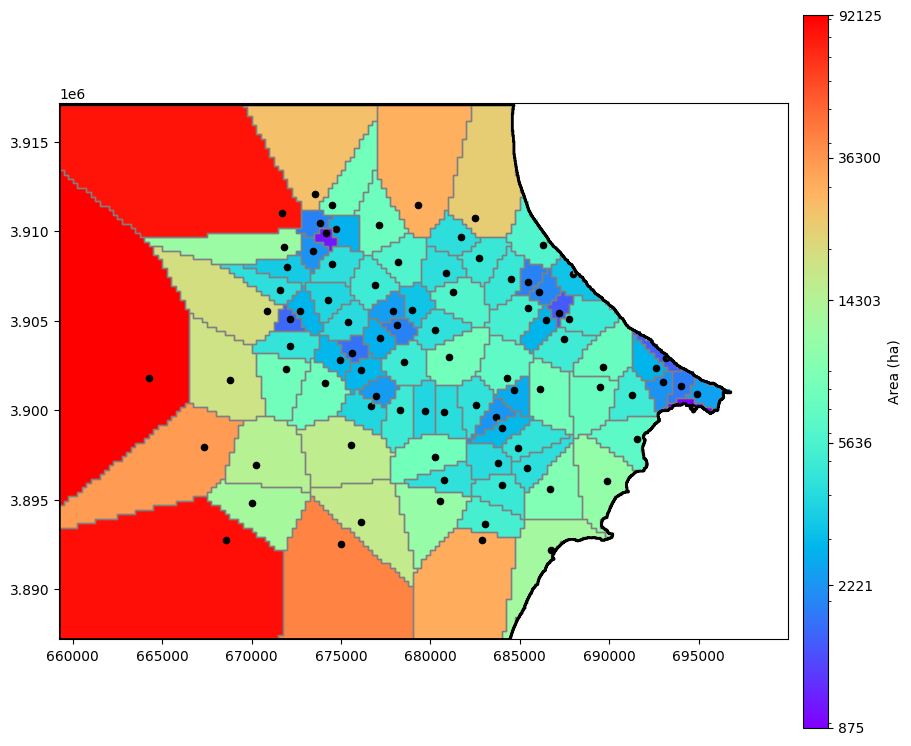

In [64]:
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm

valid_mask = np.asarray(regular_grid['mask']).reshape(ny, nx).astype(bool)
vor_grid = np.asarray(regular_grid['voronoi_region']).reshape(ny, nx).astype(float)

valid_regions = vor_grid[valid_mask]
valid_regions = valid_regions[~np.isnan(valid_regions)].astype(int)

counts = np.bincount(valid_regions, minlength=len(sites))
sites['ncells'] = counts

region_size_grid = counts[cell_region_index].astype(float)
region_size_grid[~valid_mask] = np.nan
region_size_grid = region_size_grid * regular_grid['mask'] * regular_grid['L_cell']**2 / 1e3

finite_vals = region_size_grid[np.isfinite(region_size_grid)]
positive_vals = finite_vals[finite_vals > 0]
vmin = float(positive_vals.min())
vmax = float(positive_vals.max())

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
mesh = ax.pcolormesh(
    x_grid,
    y_grid,
    region_size_grid,
    cmap="rainbow",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    shading="nearest",
)
ax.set_aspect("equal")
ax.scatter(points[:, 0], points[:, 1], color='black', s=20)
voronoi_gdf.boundary.plot(ax=ax, color="grey", linewidth=1)
gdf.boundary.plot(ax=ax, color="black", linewidth=2)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    label='Area (ha)',
    fraction=0.045,
    pad=0.02,
    shrink=0.9,
    aspect=28,
    anchor=(0.0, 0.5),
)
base_ticks = np.geomspace(vmin, vmax, num=6)
ticks = np.unique(np.concatenate([base_ticks, [vmin, vmax]]))
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" if t < 10 else f"{t:.1f}" if t < 100 else f"{t:.0f}" for t in ticks])

plt.show()


Area constraint applied: A_max = 20000 ha
Total cells removed: 9640
Voronoi polygons saved to input_data/voronoi_regions.shp
Voronoi polygons created: 90 regions


c:\Users\Pc\OneDrive\Documents\repos\Roman-Chebba-agriculture\.venv\Lib\site-packages\pyogrio\geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


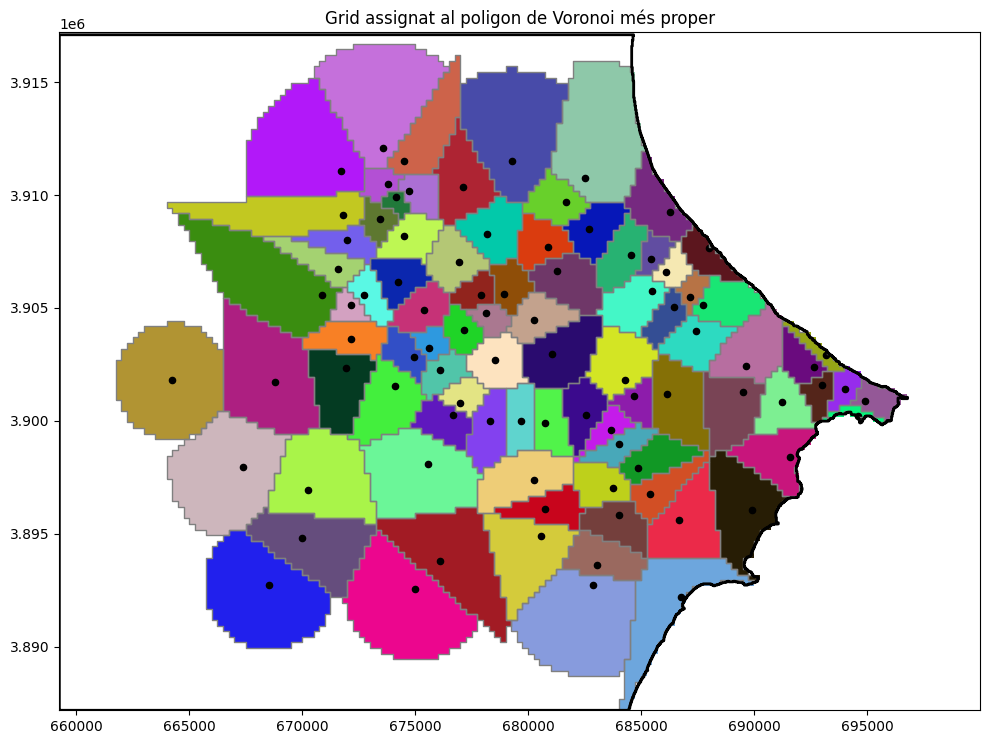

In [65]:
import re, yaml
with open("parameters.yaml", "r", encoding="utf-8") as f:
    raw_params = f.read()
# Accept YAML-like files with trailing commas before comments or end-of-line.
cleaned_params = re.sub(r",(?=\s*(#.*)?$)", "", raw_params, flags=re.MULTILINE)
params = yaml.safe_load(cleaned_params)

A_max = params["A_max"]

# Apply area constraint to Voronoi regions
# For regions exceeding A_max, mark the farthest cells as NaN until area limit is satisfied

L_cell = regular_grid['L_cell']
cell_area_ha = (L_cell ** 2) / 1e3  # Area in hectares

# Create a copy of voronoi_region to work with
voronoi_region_limited = np.asarray(regular_grid['voronoi_region']).reshape(ny, nx).copy()

# Process each Voronoi region
for site_idx in range(len(sites)):
    # Find all cells assigned to this region
    site_mask = voronoi_region_limited == site_idx
    
    if not np.any(site_mask):
        continue
    
    # Calculate current area
    site_cell_count = np.sum(site_mask)
    site_area = site_cell_count * cell_area_ha
    
    # If area exceeds limit, remove farthest cells
    if site_area > A_max:
        # Get coordinates of site
        site_coords = points[site_idx]
        
        # Get coordinates of cells in this region
        rows, cols = np.where(site_mask)
        cell_coords = np.column_stack([
            x_grid[rows, cols],
            y_grid[rows, cols]
        ])
        
        # Calculate distances from cells to site
        d2 = np.sum((cell_coords - site_coords) ** 2, axis=1)
        
        # Sort by distance (farthest first)
        farthest_first = np.argsort(-d2)
        
        # Remove cells from farthest until area constraint is satisfied
        n_remove = 0
        for idx in farthest_first:
            current_area = (site_cell_count - n_remove) * cell_area_ha
            if current_area <= A_max:
                break
            # Mark cell as NaN
            voronoi_region_limited[rows[idx], cols[idx]] = np.nan
            n_remove += 1
        
        # Update counts after removal
        removed_cell_indices = []
        for idx in farthest_first[:n_remove]:
            removed_cell_indices.append((rows[idx], cols[idx]))

# Update the regular_grid with the limited voronoi regions
regular_grid['voronoi_region'] = voronoi_region_limited

print(f"Area constraint applied: A_max = {A_max} ha")
print(f"Total cells removed: {np.isnan(regular_grid['voronoi_region']).sum()}")

voronoi_gdf = create_voronoi_polygons(
    voronoi_region=regular_grid['voronoi_region'],
    L_cell=regular_grid['L_cell'],
    sites=sites,
    x_grid=x_grid,
    y_grid=y_grid,
    gdf=gdf,
    save_path="input_data/voronoi_regions.shp"  # Don't save to file
)

fig, ax = plt.subplots(figsize=(10, 10))
N = int(np.nanmax(cell_region_index)) + 1
rng = np.random.default_rng(42)
cmap = ListedColormap(rng.random((N, 3)))
norm = BoundaryNorm(np.arange(-0.5, N + 0.5, 1), cmap.N)
mesh = ax.pcolormesh(
    x_grid,
    y_grid,
    regular_grid['voronoi_region'],
    cmap=cmap,
    norm=norm,
    shading="nearest",
)
ax.scatter(points[:, 0], points[:, 1], color='black', s=20, label='Capitals')
ax.set_title('Grid assignat al poligon de Voronoi més proper')
voronoi_gdf.boundary.plot(ax=ax, color="grey", linewidth=1)
gdf.boundary.plot(ax=ax, color="black", linewidth=2)
plt.tight_layout()
plt.show()



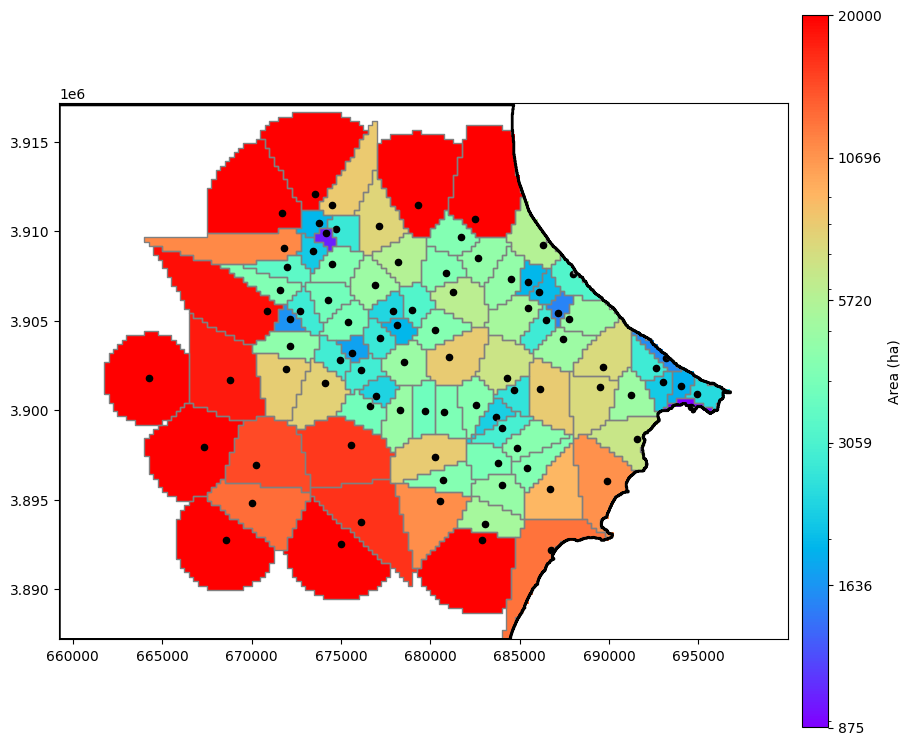

In [66]:
regular_grid['mask'] = ~np.isnan(regular_grid['voronoi_region'])
valid_mask = np.asarray(regular_grid['mask']).reshape(ny, nx).astype(bool)
vor_grid = np.asarray(regular_grid['voronoi_region']).reshape(ny, nx).astype(float)

valid_regions = vor_grid[valid_mask]
valid_regions = valid_regions[~np.isnan(valid_regions)].astype(int)

counts = np.bincount(valid_regions, minlength=len(sites))
sites['ncells'] = counts

region_size_grid = counts[cell_region_index].astype(float)
region_size_grid[~valid_mask] = np.nan
region_size_grid = region_size_grid * regular_grid['mask'] * regular_grid['L_cell']**2 / 1e3

finite_vals = region_size_grid[np.isfinite(region_size_grid)]
positive_vals = finite_vals[finite_vals > 0]
vmin = float(positive_vals.min())
vmax = float(positive_vals.max())

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
mesh = ax.pcolormesh(
    x_grid,
    y_grid,
    region_size_grid,
    cmap="rainbow",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    shading="nearest",
)
ax.set_aspect("equal")
ax.scatter(points[:, 0], points[:, 1], color='black', s=20)
voronoi_gdf.boundary.plot(ax=ax, color="grey", linewidth=1)
gdf.boundary.plot(ax=ax, color="black", linewidth=2)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    label='Area (ha)',
    fraction=0.045,
    pad=0.02,
    shrink=0.9,
    aspect=28,
    anchor=(0.0, 0.5),
)
base_ticks = np.geomspace(vmin, vmax, num=6)
ticks = np.unique(np.concatenate([base_ticks, [vmin, vmax]]))
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.2f}" if t < 10 else f"{t:.1f}" if t < 100 else f"{t:.0f}" for t in ticks])

plt.show()

In [68]:
cell_ids = []
for j in range(ny):
    for i in range(nx):
        cell = regular_grid['voronoi_region'][j, i]
        if np.isnan(cell):
            cell_ids.append(np.nan)
        else:
            cell_ids.append(sites.loc[int(cell), 'id'])

regular_grid['voronoi_ids'] = np.array(cell_ids).reshape(ny, nx)
pd.to_pickle(regular_grid, "input_data/regular_grid_with_voronoi.pkl")
print(regular_grid)

{'x_center': array([[659374., 659624., 659874., ..., 699374., 699624., 699874.],
       [659374., 659624., 659874., ..., 699374., 699624., 699874.],
       [659374., 659624., 659874., ..., 699374., 699624., 699874.],
       ...,
       [659374., 659624., 659874., ..., 699374., 699624., 699874.],
       [659374., 659624., 659874., ..., 699374., 699624., 699874.],
       [659374., 659624., 659874., ..., 699374., 699624., 699874.]],
      shape=(120, 163)), 'y_center': array([[3887303., 3887303., 3887303., ..., 3887303., 3887303., 3887303.],
       [3887553., 3887553., 3887553., ..., 3887553., 3887553., 3887553.],
       [3887803., 3887803., 3887803., ..., 3887803., 3887803., 3887803.],
       ...,
       [3916553., 3916553., 3916553., ..., 3916553., 3916553., 3916553.],
       [3916803., 3916803., 3916803., ..., 3916803., 3916803., 3916803.],
       [3917053., 3917053., 3917053., ..., 3917053., 3917053., 3917053.]],
      shape=(120, 163)), 'soil': array([[ 2.,  2.,  2., ..., nan, nan, n

In [ ]:
sites["cell_indices"] = sites["id"].apply(
    lambda sid: np.flatnonzero(regular_grid['voronoi_ids'].ravel() == sid).tolist()
)

sites.to_csv("input_data/sites_voronoi.csv", index=False)

[15702, 15703, 15704, 15705, 15865, 15866, 15867, 15868, 16027, 16028, 16029, 16030, 16031, 16032, 16189, 16190, 16191, 16192, 16193, 16194, 16195, 16196, 16352, 16353, 16354, 16355, 16356, 16357, 16358, 16359, 16514, 16515, 16516, 16517, 16518, 16519, 16520, 16521, 16522, 16523, 16677, 16678, 16679, 16680, 16681, 16682, 16683, 16684, 16685, 16686, 16687, 16839, 16840, 16841, 16842, 16843, 16844, 16845, 16846, 16847, 16848, 16849, 16850, 17002, 17003, 17004, 17005, 17006, 17007, 17008, 17009, 17010, 17011, 17012, 17013, 17014, 17164, 17165, 17166, 17167, 17168, 17169, 17170, 17171, 17172, 17173, 17174, 17175, 17176, 17177, 17178, 17326, 17327, 17328, 17329, 17330, 17331, 17332, 17333, 17334, 17335, 17336, 17337, 17338, 17339, 17340, 17341, 17489, 17490, 17491, 17492, 17493, 17494, 17495, 17496, 17497, 17498, 17499, 17500, 17501, 17502, 17503, 17504, 17505, 17651, 17652, 17653, 17654, 17655, 17656, 17657, 17658, 17659, 17660, 17661, 17662, 17663, 17664, 17665, 17666, 17667, 17668, 17669